In [1]:
import os
import pandas as pd
import numpy as np
from scipy.signal import find_peaks


In [198]:
import matplotlib as mpl
from matplotlib import font_manager

font_manager.fontManager.addfont(r"C:\Oded_data\Helvetica.ttf")  # adjust path
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['svg.fonttype'] = 'none'

# --- Global font config ---
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['svg.fonttype'] = 'none'  # keep text editable in SVGs


In [ ]:

# Define the path to the main directory

main_directory = r'C:\Oded_data\behavior_analysis\2p_ablated\ZZ_output_control_pilot'
#experimental parameters:
fps = 10
epochs_in_min = [10.5, 2, 5]
epoch_names = ['E3', 'Odor', 'E3']

# Calculate frame boundaries for the epochs
epoch_boundaries = np.insert(np.cumsum(np.array(epochs_in_min) * 60 * fps), 0, 0)


# Initialize a list to hold dataframes
all_data = []

# Loop through each subfolder in the main directory
for subfolder in os.listdir(main_directory):
    # Construct full path to the subfolder
    subfolder_path = os.path.join(main_directory, subfolder)
    
    # Check if it's indeed a directory (and not a file)
    if os.path.isdir(subfolder_path):
        
        # Extract odor and side information from the subfolder name
        print(f'subfolder {subfolder}')
        parts = subfolder.split("_")
        odor = parts[1]
        print(f'odor {odor}')
        side = parts[2]
        print(f'side {side}')
        genotype = parts[6]
        print(f'geno {genotype}')
        round = parts[5]
        print(f'round {round}')
        group = parts[4]
        print(f'group {group}')

        
        # Loop through each file in the subfolder
        for file in os.listdir(subfolder_path):
            fname = file.strip()
            if not fname.lower().endswith(".csv"):
                continue
        
            file_path = os.path.join(subfolder_path, fname)
        
            if not os.path.exists(file_path):
                print("MISSING:", repr(file_path))
                continue
            if not os.path.isfile(file_path):
                print("NOT A FILE:", repr(file_path))
                continue
        
            df = pd.read_csv(file_path, skiprows=1)

            
            # Replace (0,0) with NaN in the primary data file
            df.loc[(df["HeadPosX"] == 0) & (df["HeadPosY"] == 0), ["HeadPosX", "HeadPosY"]] = np.nan
               
            # Add odor and side information to the dataframe
            df["Odor"] = odor
            df["Side"] = side
            df["Filename"] = file  # Adding filename to the dataframe
            df["genotype"] = genotype
            df["round"] = round
            df["group"] = group


            # Normalize HeadPosX and HeadPosY
            df["normalized_x"] = (df["HeadPosX"] - df["HeadPosX"].min()) / (df["HeadPosX"].max() - df["HeadPosX"].min())
            df["normalized_y"] = (df["HeadPosY"] - df["HeadPosY"].min()) / (df["HeadPosY"].max() - df["HeadPosY"].min())

            # Flip normalized_y if side is B
            if side == 'B':
                df["normalized_y"] = 1 - df["normalized_y"]
            
            pixel_width_cm = 0.085 
            pixel_height_cm = 0.085 
            
            
            # Calculate the physical differences in X and Y directions
            diff_x_cm = df["HeadPosX"].diff() * pixel_width_cm
            diff_y_cm = df["HeadPosY"].diff() * pixel_height_cm
            
            # === ZebraZoom-style heading (using Tail4 + Tail5)
            tail_x = df[["TailPosX4", "TailPosX5"]].mean(axis=1)
            tail_y = df[["TailPosY4", "TailPosY5"]].mean(axis=1)
            dx_ZZ = df["HeadPosX"] - tail_x
            dy_ZZ = df["HeadPosY"] - tail_y
            heading_angle = np.degrees(np.arctan2(dy_ZZ, dx_ZZ))
            # Flip the heading angle if side is 'B'
            if side == 'B':
                heading_angle = -heading_angle
                
            df["HeadingAngle"] = heading_angle

            # Calculate movement bouts (speedData)
            speedData = np.sqrt(diff_x_cm**2 + diff_y_cm**2)
            df["Speed"] = speedData

            # Detect movement bouts using find_peaks
            min_peak_prom = 0.2
            movementBouts = np.zeros_like(speedData)
            peaks, _ = find_peaks(speedData, prominence=min_peak_prom, distance=3)
            peaks = peaks - 1
            # Ensure no negative indices after shifting
            peaks = peaks[peaks >= 0]

            movementBouts[peaks] = 1
            df["MovementBouts"] = movementBouts
            # Calculate heading across bouts
            def calculate_heading_across_bouts(df):
                heading = np.full(len(df), np.nan)
                bout_indices = np.where(df["MovementBouts"].values == 1)[0]
                for i in range(len(bout_indices) - 1):
                    start_idx = bout_indices[i]
                    end_idx = bout_indices[i + 1]
                    dx = df["HeadPosX"].iloc[end_idx] - df["HeadPosX"].iloc[start_idx]
                    dy = df["HeadPosY"].iloc[end_idx] - df["HeadPosY"].iloc[start_idx]
                    angle = np.degrees(np.arctan2(dy, dx))
                    heading[start_idx:end_idx] = angle
                return heading

            df["HeadingAngle_bout"] = calculate_heading_across_bouts(df)                
            # Append the dataframe to the list
            all_data.append(df)

# Concatenate all dataframes into one
final_df = pd.concat(all_data, ignore_index=True)
final_df.rename(columns={final_df.columns[0]: 'frames'}, inplace=True)
# Experimental parameters
fps = 10

# Calculate the frame boundaries for each epoch
epoch_boundaries = np.cumsum(np.array(epochs_in_min) * 60 * fps)

# Split the data based on the epoch boundaries
def bin_data_by_epochs(data):
    if data['frames'] <= epoch_boundaries[0]:
        return 'E3_pre'
    elif data['frames'] <= epoch_boundaries[1]:
        return 'Odour_time'
    else:
        return 'E3_post'

# Apply the binning function to the dataframe
final_df['Epoch'] = final_df.apply(bin_data_by_epochs, axis=1)


subfolder 20251216_ATP500uM_A_1_G1_R1_control__2025-12-16-090150-0000_2026_01_16-14_10_30
odor ATP500uM
side A
geno control
round R1
group G1
subfolder 20251216_ATP500uM_B_1_G2_R1_control__2025-12-16-092705-0000_2026_01_16-14_10_30
odor ATP500uM
side B
geno control
round R1
group G2
subfolder 20251216_ATP500uM_B_1_G3_R1_control__2025-12-16-095301-0000_2026_01_16-14_10_30
odor ATP500uM
side B
geno control
round R1
group G3
subfolder 20251216_TCA300uM_A_1_G3_R2_control__2025-12-16-162758-0000_2026_01_16-11_48_11
odor TCA300uM
side A
geno control
round R2
group G3
subfolder 20251216_TCA300uM_B_1_G1_R2_control__2025-12-16-140028-0000_2026_01_16-11_53_45
odor TCA300uM
side B
geno control
round R2
group G1
subfolder 20251216_TCA300uM_B_2_G2_R2_control__2025-12-16-142744-0000_2026_01_16-12_03_58
odor TCA300uM
side B
geno control
round R2
group G2
subfolder 20251217_ATP500uM_A_1_G1_R1_control__2025-12-17-085624-0000_2026_01_16-22_13_17
odor ATP500uM
side A
geno control
round R1
group G1
subfol

In [223]:
medianRange = [0.25, 0.75]
immobilityThreshold = 1.0
consecutiveFrames = 600 

# List of columns to keep
columns_to_keep = [
    "frames", "HeadPosX", "HeadPosY", "TailPosX1","TailPosY1","TailPosX2","TailPosY2","TailPosX3","TailPosY3",
    'TailPosX4', 'TailPosY4', 'TailPosX5', 'TailPosY5', 'TailPosX6', 'TailPosY6', 'TailPosX7', 'TailPosY7', 
    'TailPosX8', 'TailPosY8', 'TailPosX9', 'TailPosY9',"Odor","Side","Filename", "HeadingAngle", 
    "normalized_x", "normalized_y", "Speed", "MovementBouts", "Epoch","genotype","round","group"
]

def filter_and_analyze_data(df):
    df = df[columns_to_keep]  # Keep only the specified columns

    odorLabels = df['Odor'].unique()
    filtered_data = []
    removed_data = []
    reasons = []
    median_out = {}
    missing_data = {}
    speed_data = {}

    for odor in odorLabels:
        odor_df = df[df['Odor'] == odor]
        median_out[odor] = 0
        missing_data[odor] = 0
        speed_data[odor] = 0
        
        # Filter tracks based on criteria
        for _, track in odor_df.groupby('Filename'):
            reason_for_removal = None
            biasData = track['normalized_y'].iloc[:6300]
            tracks = track['normalized_y'].iloc[5000:8500]
            speed = track['Speed'].iloc[:6300]
            immobileFrames = speed < immobilityThreshold
            extended_immobility = any(immobileFrames.rolling(window=consecutiveFrames).sum() == consecutiveFrames)

            trackPassedFilter = True
            biasData_noNaN = biasData.dropna()
            validData = tracks.dropna()
            medianVal = biasData_noNaN.median()
            meanVal = biasData_noNaN.mean()
            
            
            if len(validData) < len(tracks) / 2:
                reason_for_removal = 'Missing Data'
                missing_data[odor] += 1
                trackPassedFilter = False

            elif meanVal < medianRange[0] or meanVal > medianRange[1]:
                reason_for_removal = 'Positional Bias'
                median_out[odor] += 1
                trackPassedFilter = False

            elif extended_immobility:
                reason_for_removal = 'Extended Immobility'
                speed_data[odor] += 1
                trackPassedFilter = False

            if trackPassedFilter:
                filtered_data.append(track)
            else:
                reason_df = track.copy()
                reason_df['Reason'] = reason_for_removal
                removed_data.append(reason_df)
                
    # Check if filtered_data and removed_data are empty
    if filtered_data:
        filtered_df = pd.concat(filtered_data, ignore_index=True)
    else:
        filtered_df = pd.DataFrame(columns=df.columns)
        
    if removed_data:
        removed_df = pd.concat(removed_data, ignore_index=True)
    else:
        removed_df = pd.DataFrame(columns=df.columns + ['Reason'])


    return filtered_df, removed_df, speed_data, median_out, missing_data

# Apply the filtering and analysis
[filtered_df, removed_df, speed_data, median_out, missing_data] = filter_and_analyze_data(final_df)


In [224]:
print(f"total number of larvae {len(final_df['Filename'].unique())}")

print(f"total number of larvae kept was {len(filtered_df['Filename'].unique())}")
print(f"total number of larvae removed was {len(removed_df['Filename'].unique())}")


total number of larvae 72
total number of larvae kept was 43
total number of larvae removed was 29


In [225]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Global, do this once BEFORE plotting ---
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['svg.fonttype'] = 'none'     # keep text editable in SVGs
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['ytick.labelsize'] = 6
# Optional: make math text match sans-serif
mpl.rcParams['mathtext.fontset'] = 'dejavusans'

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

def stdshade(data, alpha=0.5, color='r', x=None, smooth=1, ax=None, plot_median=False, plot_sem=False,epoch_l_font=12,line_width_s=2):
    """
    Plot mean and sem/std coming from a matrix of data, at which each row is an observation.
    sem/std is shown as shading.
    Args:
        - data: A matrix where each row is an observation
        - alpha: Transparency level for the shaded region (0: transparent, 1: opaque)
        - color: Color for the line and shaded region
        - x: X values corresponding to data columns
        - smooth: Smoothing factor for the mean curve
        - ax: Axis to plot on (if None, uses the current axis)
        - plot_median: Boolean to decide if the median should be plotted
        - plot_sem: Boolean to decide if the shading represents SEM instead of STD
    """
    if ax is None:
        ax = plt.gca()
    
    if x is None:
        x = np.arange(data.shape[1])
        
    mean = np.nanmean(data, axis=0)
    median = np.nanmedian(data, axis=0)
    std = np.nanstd(data, axis=0)
    n = data.shape[0]  # Number of observations
    
    # Calculate SEM if plot_sem is True
    if plot_sem:
        sem = std / np.sqrt(n)
    
    # Smoothing (simple moving average)
    if smooth > 1:
        kernel = np.ones(smooth) / smooth
        mean = np.convolve(mean, kernel, mode='same')
        median = np.convolve(median, kernel, mode='same')
    
    ax.plot(x, mean, color=color, linewidth=line_width_s)
    if plot_median:
        ax.plot(x, median, color='g', linewidth=line_width_s, linestyle='--', label='Median')  # Green dashed line for median
    
    # Use SEM for shading if plot_sem is True, otherwise use STD
    if plot_sem:
        ax.fill_between(x, mean-sem, mean+sem, color=color, alpha=alpha)
    else:
        ax.fill_between(x, mean-std, mean+std, color=color, alpha=alpha)

    # Add vertical lines for epoch boundaries with custom dash pattern
    for i, boundary in enumerate(epoch_boundaries[:-1]):
        ax.axvline(x=boundary, color='brown', linestyle='--', linewidth=0.5, dashes=(5, 4))  # Custom dash pattern: 5 pixels dash, 2 pixels space
        if i < len(epoch_boundaries) - 1:
            ax.axvline(x=epoch_boundaries[i+1], color='brown', linestyle='--', linewidth=0.5, dashes=(5, 4))  # Repeat for consistency
            ax.text((boundary + epoch_boundaries[i+1]) / 2, 0.9, epoch_names[i], ha='left', va='top', fontsize=epoch_l_font, fontweight='bold')
            if i == 1:  # Second epoch
                # Fill only top half for the second epoch
                ax.fill_betweenx(y=[0.5, 1], x1=boundary, x2=epoch_boundaries[i+1], color='brown', alpha=0.05)

    ax.axhline(0.5, color='k', linestyle='--')  # Dashed horizontal line
    ax.set_ylim([0, 1])  # Set y-axis limit to [0, 1]
    ax.set_xlim([300, 9000])

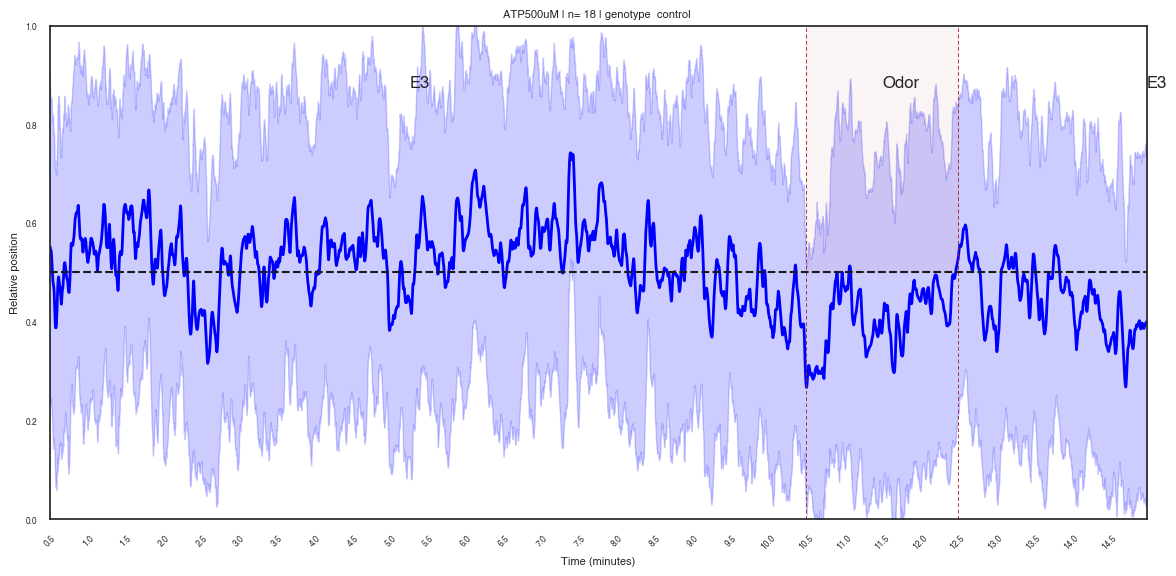

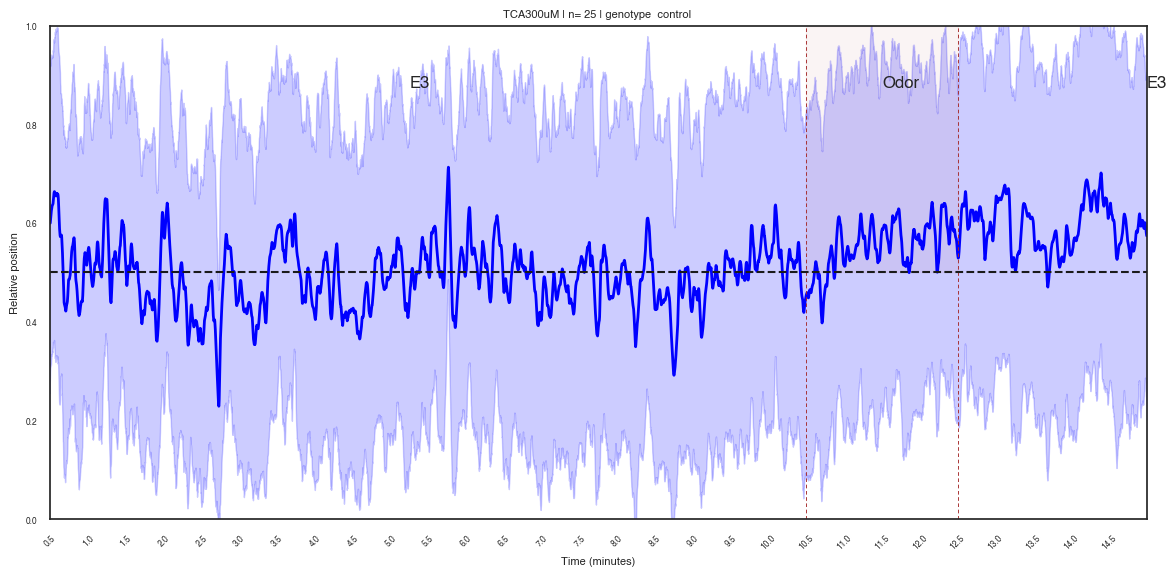

saved files in U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\2pAblation_plots\202601_plots


In [226]:
# plot normalized y values per odor using stdshade
odors = filtered_df['Odor'].unique()
epoch_boundaries = np.insert(np.cumsum(np.array(epochs_in_min) * 60 * fps), 0, 0)
genotypes = filtered_df['genotype'].unique()
rounds = filtered_df['round'].unique()

# Plot for each odor
for odor in odors:
    subset_all = filtered_df[
        (filtered_df['Odor'] == odor) ]#&
    #     (filtered_df['round'] == "R1")
    # ]

    for geno in genotypes:
        subset = subset_all[subset_all['genotype'] == geno]

        # for r in rounds:
            # subset = subset_2[subset_2['round'] == r]
            
        plt.figure(figsize=(12, 6))
        
        # Group by filename, treating each file as a separate observation and crop frames 100 to 12000
        grouped = subset.groupby('Filename')['normalized_y'].apply(lambda x: np.array(x[300:9500]))
        valid_arrays = [arr for arr in grouped if arr.size > 0]  # Filter out empty arrays
        data_matrix = np.vstack(valid_arrays)
        num_tracks = data_matrix.shape[0]  # Number of tracks corresponds to the number of rows in the matrix
        stdshade(data_matrix, color='blue', alpha=0.2, x=np.arange(1, data_matrix.shape[1] + 1),smooth=10,plot_median=False,plot_sem=False)
        
        plt.title(f'{odor} | n= {num_tracks} | genotype  {geno} ')
        plt.xlabel('Time (minutes)')
        plt.ylabel('Relative position')
            # Adjust the x-axis tick labels to display time in seconds
        # Set x-axis ticks and labels to display time in seconds
        frame_ticks = np.arange(300, 9000, step=300)  # ticks every 500 frames
        #time_ticks = frame_ticks / fps
        fpm = 600
        time_ticks = frame_ticks / fpm
        plt.xticks(frame_ticks, labels=[f"{t:.1f}" for t in time_ticks], rotation=45)
    
        plt.grid(False)
        plt.tight_layout()
     # Modify file path to include the odor and side names
        plot_dir =r"U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\2pAblation_plots\202601_plots"

        file_path =  os.path.join(plot_dir,f"normalizedY_stShade_{odor}_filtered.png")
    
        png_file_path = os.path.join(plot_dir,f"control_normalizedY_{odor}_{geno}.png")
        svg_file_path = os.path.join(plot_dir,f"control_normalizedY_{odor}_{geno}.svg")
            
        # # Save both PNG and SVG
        plt.savefig(png_file_path)
        plt.savefig(svg_file_path, format='svg')
        plt.show()   
print(f'saved files in {plot_dir}')

In [227]:
import pandas as pd
import numpy as np
import re

# --- regexes (robust to token shifts) ---
RE_DAY  = re.compile(r"allData_(\d{8})_")
RE_GRP  = re.compile(r"_(G\d+)_")
RE_RND  = re.compile(r"_(R[12])_")
RE_WELL = re.compile(r"_wellNumber(\d+)")
RE_TS   = re.compile(r"__(\d{4}-\d{2}-\d{2})-(\d{6})")

def parse_filename_meta(fn: str) -> dict:
    s = str(fn)

    day  = RE_DAY.search(s)
    grp  = RE_GRP.search(s)
    rnd  = RE_RND.search(s)
    well = RE_WELL.search(s)
    ts   = RE_TS.search(s)

    day  = day.group(1) if day else np.nan
    grp  = grp.group(1) if grp else np.nan
    rnd  = rnd.group(1) if rnd else np.nan
    well = int(well.group(1)) if well else np.nan

    if ts:
        ts_str = f"{ts.group(1)}-{ts.group(2)}"
    else:
        ts_str = np.nan

    return {
        "Filename": s,
        "Day": day,
        "Group": grp,
        "Well": well,
        "Round_in_name": rnd,
        "Timestamp_Str": ts_str,
    }

def build_pairing_table_from_final_df(
    final_df: pd.DataFrame,
    qc_print: bool = True,
    expected_n_rounds: int | None = 2,
) -> pd.DataFrame:
    if "Filename" not in final_df.columns:
        raise ValueError("final_df must contain a 'Filename' column.")

    # One row per FILE
    files = pd.DataFrame({"Filename": final_df["Filename"].astype(str).unique()})

    meta = files["Filename"].apply(parse_filename_meta).apply(pd.Series)
    files = files.merge(meta, on="Filename", how="left")

    # Optional: carry genotype/odor from final_df if present and well-defined per file
    carry_cols = []
    for c in ["genotype", "Odor", "odor", "Treatment", "condition"]:
        if c in final_df.columns:
            carry_cols.append(c)

    if carry_cols:
        file_ann = (
            final_df[["Filename"] + carry_cols]
            .copy()
            .assign(Filename=lambda d: d["Filename"].astype(str))
            .drop_duplicates()
        )
        # If any file maps to multiple annotations, keep first but flag in QC
        # (QC below will catch this)
        files = files.merge(file_ann, on="Filename", how="left")

    # Animal key used for pairing
    files["Animal_ID"] = (
        files["Day"].astype(str) + "_" + files["Group"].astype(str) + "_W" + files["Well"].astype(str)
    )

    # Parse timestamp to order sessions
    files["Timestamp"] = pd.to_datetime(files["Timestamp_Str"], format="%Y-%m-%d-%H%M%S", errors="coerce")

    # Session order (chronological) within animal
    files["Session_Order"] = (
        files.groupby("Animal_ID")["Timestamp"]
             .rank(method="dense", ascending=True)
             .astype("Int64")
    )
    # After computing files["Session_Order"]
    files["Is_First"] = files["Session_Order"].eq(1)
    
    files["Session_Label"] = pd.Categorical(
        np.where(files["Session_Order"].eq(1), "first",
                 np.where(files["Session_Order"].eq(2), "second", "later")),
        categories=["first", "second", "later"],
        ordered=True
    )
    
    # (Optional) also keep a 1/2 only label for paired datasets
    files["Round_FirstSecond"] = files["Session_Order"].where(files["Session_Order"].isin([1, 2]), pd.NA).astype("Int64")

    # ---- QC ----
    if qc_print:
        print("\n==============================")
        print("[QC] Pairing table (from final_df)")
        print("==============================")
        print(f"[QC] Unique files: {len(files):,}")
        print(f"[QC] Unique Animal_IDs: {files['Animal_ID'].nunique():,}")

        bad_meta = files[files["Day"].isna() | files["Group"].isna() | files["Well"].isna()]
        if len(bad_meta) > 0:
            print(f"[QC] WARNING: {len(bad_meta)} files failed Day/Group/Well parsing. Example:")
            print(bad_meta[["Filename","Day","Group","Well"]].head(10).to_string(index=False))

        bad_ts = files["Timestamp"].isna().sum()
        if bad_ts:
            print(f"[QC] WARNING: {bad_ts} files failed timestamp parsing. Example:")
            print(files.loc[files["Timestamp"].isna(), "Filename"].head(10).to_string(index=False))

        # Are annotations unique per file?
        for c in carry_cols:
            nuniq = final_df.groupby(final_df["Filename"].astype(str))[c].nunique(dropna=False)
            bad = nuniq[nuniq > 1]
            if len(bad) > 0:
                print(f"[QC] WARNING: {len(bad)} filenames have >1 unique '{c}' in final_df (annotation not file-constant).")

        if expected_n_rounds is not None:
            n_sessions = (
                files[["Animal_ID","Session_Order"]].drop_duplicates()
                .groupby("Animal_ID")["Session_Order"].nunique(dropna=True)
            )
            bad = n_sessions[n_sessions != expected_n_rounds]
            if len(bad) > 0:
                print(f"\n[QC] WARNING: {len(bad)} Animal_ID(s) do not have exactly {expected_n_rounds} sessions in final_df:")
                print(bad.sort_values().head(30).to_string())
            else:
                print(f"\n[QC] OK: All Animal_IDs have exactly {expected_n_rounds} sessions in final_df.")

        # Show a few example animals
        print("\n[QC] Example animals:")
        show = (
            files[["Animal_ID","Session_Order","Timestamp_Str","Round_in_name","Filename"]]
            .drop_duplicates()
            .sort_values(["Animal_ID","Session_Order"])
        )
        for aid, g in show.groupby("Animal_ID"):
            print(f"\nAnimal_ID={aid} | sessions={g['Session_Order'].dropna().astype(int).tolist()}")
            for _, r in g.iterrows():
                so = int(r["Session_Order"]) if pd.notna(r["Session_Order"]) else None
                print(f"  S{so} | ts={r['Timestamp_Str']} | round_in_name={r['Round_in_name']} | {r['Filename']}")
            # keep it short
            if show["Animal_ID"].nunique() > 10:
                break

    return files
pairing_table = build_pairing_table_from_final_df(final_df, qc_print=True, expected_n_rounds=2)



[QC] Pairing table (from final_df)
[QC] Unique files: 72
[QC] Unique Animal_IDs: 36

[QC] OK: All Animal_IDs have exactly 2 sessions in final_df.

[QC] Example animals:

Animal_ID=20251216_G1_W0 | sessions=[1, 2]
  S1 | ts=2025-12-16-090150 | round_in_name=R1 | allData_20251216_ATP500uM_A_1_G1_R1_control__2025-12-16-090150-0000_wellNumber0_animal0.csv
  S2 | ts=2025-12-16-140028 | round_in_name=R2 | allData_20251216_TCA300uM_B_1_G1_R2_control__2025-12-16-140028-0000_wellNumber0_animal0.csv


In [228]:
# Only pairing metadata (no Odor/genotype projection)
pairing_min = pairing_table[
    ["Filename", "Animal_ID", "Session_Order", "Session_Label", "Is_First",
     "Timestamp_Str", "Timestamp", "Round_in_name"]
].copy()

filtered_df_projected = (
    filtered_df.copy()
    .assign(Filename=lambda d: d["Filename"].astype(str))
    .merge(pairing_min, on="Filename", how="left", validate="many_to_one")
)


missing = filtered_df_projected["Session_Order"].isna().sum()
print(f"[QC] Frames in filtered_df without pairing info: {missing:,} / {len(filtered_df_projected):,}")


[QC] Frames in filtered_df without pairing info: 0 / 563,130


In [242]:
import numpy as np
import pandas as pd

FPS = 10  # frames/sec

# -----------------------------
# Preference from Odour_time
# -----------------------------
od = filtered_df_projected[filtered_df_projected["Epoch"] == "Odour_time"].copy()
od["pref_bin"] = (od["normalized_y"] > 0.5).astype(int)

pref_by_file = (
    od.groupby("Filename", dropna=False)
      .agg(
          Avg_Preference=("pref_bin", "mean"),
          n_frames_odor=("frames", "count"),
      )
      .reset_index()
)

# -----------------------------
# Locomotion from E3_pre
# -----------------------------
pre = filtered_df_projected[filtered_df_projected["Epoch"] == "E3_pre"].copy()

loc_by_file = (
    pre.groupby("Filename", dropna=False)
       .agg(
           Avg_Speed_cm_per_frame=("Speed", "mean"),
           Total_Distance_cm=("Speed", "sum"),   # Speed is cm/frame
           n_frames_pre=("frames", "count"),
       )
       .reset_index()
)

loc_by_file["Avg_Speed_cm_s"] = loc_by_file["Avg_Speed_cm_per_frame"] * FPS
loc_by_file["Pre_Duration_s"] = loc_by_file["n_frames_pre"] / FPS

# -----------------------------
# Merge into one trial_stats
# -----------------------------
trial_stats = (
    pref_by_file
    .merge(loc_by_file, on="Filename", how="outer", validate="one_to_one")
    .merge(
        pairing_min[["Filename","Animal_ID","Session_Order","Session_Label","Is_First","Timestamp_Str","Timestamp"]],
        on="Filename",
        how="left",
        validate="one_to_one"
    )
    .merge(
        filtered_df_projected[["Filename","Odor","genotype"]].drop_duplicates("Filename"),
        on="Filename",
        how="left",
        validate="one_to_one"
    )
    .sort_values(["Animal_ID","Session_Order"])
)

# -----------------------------
# QC: which animals have which rounds (based on analyzable rows in trial_stats)
# -----------------------------
qc = (
    trial_stats.loc[trial_stats["Session_Order"].notna(), ["Animal_ID","Session_Order","Filename"]]
    .drop_duplicates()
    .groupby("Animal_ID")["Session_Order"]
    .apply(lambda x: sorted([int(v) for v in x.dropna().unique()]))
)

print(qc.value_counts().to_string())

# Optional QC: how many files lack one of the epochs after filtering?
print("\n[QC] Files missing Odour_time metrics:", int(trial_stats["Avg_Preference"].isna().sum()))
print("[QC] Files missing E3_pre locomotion metrics:", int(trial_stats["Avg_Speed_cm_s"].isna().sum()))


Session_Order
[2]       15
[1, 2]    12
[1]        4

[QC] Files missing Odour_time metrics: 0
[QC] Files missing E3_pre locomotion metrics: 0


[QC] Paired animals used: 12

Speed:    paired t-test (ttest_rel), p = 0.19, Shapiro(p_diff)=0.725
Distance: paired t-test (ttest_rel), p = 0.124, Shapiro(p_diff)=0.714
File saved to: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\2pAblation_plots\202601_plots\Control_speed_dist_paired_violin.svg


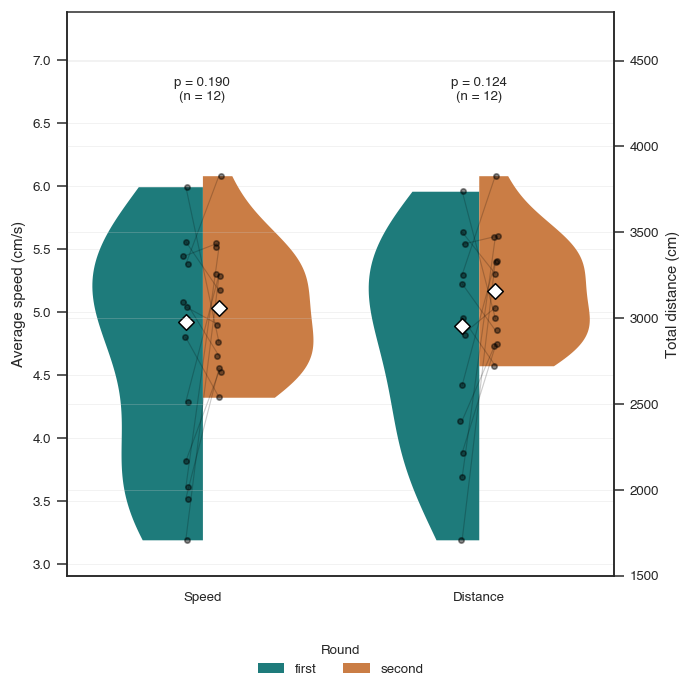

In [268]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import shapiro, ttest_rel, wilcoxon, binomtest

# ---- house style ----
TEAL   = "#0F8A8A"
ORANGE = "#E07A2F"

def set_house_style():
    import matplotlib as mpl
    sns.set_style("white")
    mpl.rcParams.update({
        "svg.fonttype": "none",
        "pdf.fonttype": 42, "ps.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "mathtext.fontset": "dejavusans",
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
        "axes.linewidth": 0.9,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
        "figure.dpi": 120,
        "savefig.transparent": True,
    })

def add_ygrid(ax, alpha=0.25):
    ax.grid(True, axis="y", alpha=alpha, linewidth=0.6)
    ax.grid(False, axis="x")


# ----------------------------
# 1) Build paired_metrics
# ----------------------------
ts2 = trial_stats[trial_stats["Session_Order"].isin([1, 2])].copy()

paired_animals = ts2.groupby("Animal_ID")["Session_Order"].nunique()
paired_animals = paired_animals[paired_animals == 2].index
ts2 = ts2[ts2["Animal_ID"].isin(paired_animals)].copy()

ts2["Session_Label_2"] = np.where(ts2["Session_Order"] == 1, "first", "second")
ts2["Session_Label_2"] = pd.Categorical(ts2["Session_Label_2"], ["first", "second"], ordered=True)

paired_metrics = (
    ts2.groupby(["Animal_ID", "Session_Label_2"], observed=True)
       .agg(
           Avg_Speed_cm_s=("Avg_Speed_cm_s", "mean"),
           Total_Distance_cm=("Total_Distance_cm", "mean"),
       )
       .reset_index()
)

print(f"[QC] Paired animals used: {paired_metrics['Animal_ID'].nunique()}")


# ----------------------------
# 2) Test selection helper
# ----------------------------
def paired_test_auto(df, value_col, alpha=0.05):
    wide = df.pivot(index="Animal_ID", columns="Session_Label_2", values=value_col).dropna()
    d = (wide["second"] - wide["first"]).dropna()

    out = {
        "value_col": value_col,
        "n": int(len(d)),
        "mean_diff": float(d.mean()) if len(d) else np.nan,
        "median_diff": float(d.median()) if len(d) else np.nan,
        "shapiro_p": np.nan,
        "method": None,
        "p": np.nan,
        "wide": wide,
    }

    if len(d) >= 3:
        try:
            out["shapiro_p"] = float(shapiro(d).pvalue)
        except Exception:
            out["shapiro_p"] = np.nan

    if (len(d) >= 3) and np.isfinite(out["shapiro_p"]) and (out["shapiro_p"] >= alpha):
        out["method"] = "paired t-test (ttest_rel)"
        out["p"] = float(ttest_rel(wide["first"], wide["second"], nan_policy="omit").pvalue)
        return out

    try:
        stat, p = wilcoxon(wide["first"], wide["second"])
        out["method"] = "Wilcoxon signed-rank"
        out["p"] = float(p)
        return out
    except Exception:
        d_nz = d[d != 0]
        if len(d_nz) == 0:
            out["method"] = "no test (all differences are 0)"
            out["p"] = 1.0
            return out

        n_pos = int((d_nz > 0).sum())
        n_tot = int(len(d_nz))
        out["method"] = "sign test (binomial)"
        out["p"] = float(binomtest(n_pos, n_tot, p=0.5, alternative="two-sided").pvalue)
        return out

def fmt_p(p):
    return "p < 1e-4" if p < 1e-4 else f"p = {p:.3g}"


res_speed = paired_test_auto(paired_metrics, "Avg_Speed_cm_s")
res_dist  = paired_test_auto(paired_metrics, "Total_Distance_cm")

print(f"\nSpeed:    {res_speed['method']}, {fmt_p(res_speed['p'])}, Shapiro(p_diff)={res_speed['shapiro_p']:.3g}")
print(f"Distance: {res_dist['method']}, {fmt_p(res_dist['p'])}, Shapiro(p_diff)={res_dist['shapiro_p']:.3g}")


# ----------------------------
# 3) Plot: TWO split-violins, dual-y
# ----------------------------
def plot_two_metric_splitviolins_dual_y(res_speed, res_dist, save_dir):
    set_house_style()
    palette = {"first": TEAL, "second": ORANGE}

    fig, ax1 = plt.subplots(figsize=(6, 6))
    ax2 = ax1.twinx()

    def to_long(wide_df, metric_name):
        long = wide_df.reset_index().melt(
            id_vars=["Animal_ID"],
            value_vars=["first", "second"],
            var_name="Round",
            value_name="Val",
        )
        long["Metric"] = metric_name
        return long

    df_speed = to_long(res_speed["wide"], "Speed")
    df_dist  = to_long(res_dist["wide"],  "Distance")

    # Split violins (one category per axis; the x positions are controlled by Metric label)
    sns.violinplot(
        data=df_speed, x="Metric", y="Val", hue="Round",
        split=True, inner=None, ax=ax1, palette=palette,
        linewidth=0, cut=0
    )
    sns.violinplot(
        data=df_dist, x="Metric", y="Val", hue="Round",
        split=True, inner=None, ax=ax2, palette=palette,
        linewidth=0, cut=0
    )

    # Paired lines + points + annotations (same as yours, just tidied)
    metrics_config = [
        {"ax": ax1, "res": res_speed, "x": 0},
        {"ax": ax2, "res": res_dist,  "x": 1},
    ]

    rng = np.random.default_rng(0)

    for cfg in metrics_config:
        ax = cfg["ax"]
        wide_df = cfg["res"]["wide"]
        x_pos = cfg["x"]
        n_obs = len(wide_df)

        y_max = wide_df[["first", "second"]].max().max()
        y_min = wide_df[["first", "second"]].min().min()
        y_range = (y_max - y_min) if (y_max - y_min) != 0 else 1.0

        bump_y = y_max + 0.20 * y_range
        ax.set_ylim(y_min - 0.10 * y_range, y_max + 0.45 * y_range)

        for _, row in wide_df.iterrows():
            y1, y2 = row["first"], row["second"]
            x1, x2 = x_pos - 0.06, x_pos + 0.06
            ax.plot([x1, x2], [y1, y2], color="black", alpha=0.20, linewidth=0.7, zorder=3)
            ax.scatter(
                [x1 + rng.uniform(-0.01, 0.01), x2 + rng.uniform(-0.01, 0.01)],
                [y1, y2],
                color="black", s=10, alpha=0.45, zorder=4
            )

                # --- MEDIAN DIAMONDS (first/second) ---
        MEDIAN_SIZE = 44
        MEDIAN_EDGE_LW = 0.9

        med_first  = float(np.nanmedian(wide_df["first"].values))
        med_second = float(np.nanmedian(wide_df["second"].values))

        x1, x2 = x_pos - 0.06, x_pos + 0.06  # same half positions you use for paired points/lines

        ax.scatter(
            x1, med_first,
            marker="D", s=MEDIAN_SIZE,
            facecolor="white", edgecolor="black",
            linewidth=MEDIAN_EDGE_LW,
            zorder=6, clip_on=False
        )
        ax.scatter(
            x2, med_second,
            marker="D", s=MEDIAN_SIZE,
            facecolor="white", edgecolor="black",
            linewidth=MEDIAN_EDGE_LW,
            zorder=6, clip_on=False
        )

        p_val = float(cfg["res"].get("p", np.nan))
        p_text = (f"p = {p_val:.3f}" if p_val >= 0.001 else "p < 0.001") if np.isfinite(p_val) else "p = NA"
        ax.text(
            x_pos, bump_y, f"{p_text}\n(n = {n_obs})",
            ha="center", va="bottom", fontsize=8,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2)
        )

        add_ygrid(ax)

    ax1.set_ylabel("Average speed (cm/s)")
    ax2.set_ylabel("Total distance (cm)")
    ax1.set_xlabel("")

    # Legend: keep one, consistent placement
    if ax1.get_legend() is not None:
        ax1.get_legend().remove()
    handles, labels = ax2.get_legend_handles_labels()
    ax2.legend(handles, labels, title="Round", loc="upper center",
               bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False)

    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(["Speed", "Distance"])

    sns.despine(ax=ax1, top=True, right=False)
    plt.tight_layout()

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    save_path = os.path.join(save_dir, "Control_speed_dist_paired_violin.svg")
    plt.savefig(save_path, format="svg", bbox_inches="tight", transparent=True)
    save_path_pdf = os.path.join(save_dir, "Control_speed_dist_paired_violin.pdf")
    plt.savefig(save_path_pdf, format="pdf", bbox_inches="tight", transparent=True)
    print(f"File saved to: {save_path}")
    plt.show()


# Usage
path = r"U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\2pAblation_plots\202601_plots"
plot_two_metric_splitviolins_dual_y(res_speed, res_dist, path)


In [249]:
# ---------------------------------------------------------
# 1) Build Sequence-Aware paired_metrics
# ---------------------------------------------------------
ts2 = trial_stats[trial_stats["Session_Order"].isin([1, 2])].copy()
ts2["Session_Label_2"] = np.where(ts2["Session_Order"] == 1, "first", "second")

# Identify the odor sequence per animal
def get_sequence(group):
    # Sort by session order to ensure correct string (e.g., "MCH -> OCT")
    sorted_group = group.sort_values("Session_Order")
    odors = sorted_group["Odor"].dropna().tolist()
    return " -> ".join(odors) if len(odors) == 2 else "Incomplete"

# Applying the function (Compatible with all Pandas versions)
seq_map = ts2.groupby("Animal_ID").apply(get_sequence).to_dict()
ts2["Sequence"] = ts2["Animal_ID"].map(seq_map)

# Filter for complete pairs and remove incomplete sequences
ts2 = ts2[ts2["Sequence"] != "Incomplete"]

# Aggregate
paired_metrics = (
    ts2.groupby(["Animal_ID", "Sequence", "Session_Label_2"], observed=True)
       .agg(Avg_Preference=("Avg_Preference", "mean"))
       .reset_index()
)

print(f"[QC] Unique animals: {paired_metrics['Animal_ID'].nunique()}")
print("Sequences found:\n", paired_metrics.groupby("Sequence")["Animal_ID"].nunique())

[QC] Unique animals: 12
Sequences found:
 Sequence
ATP500uM -> TCA300uM    8
TCA300uM -> ATP500uM    4
Name: Animal_ID, dtype: int64


C:\Users\maysel0000\AppData\Local\Temp\ipykernel_17400\698759041.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_17400\698759041.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(odors, fontweight='bold', fontsize=16)


High-visibility plot saved to: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\2pAblation_plots\202601_plots\high_visibility_odor_plot.svg


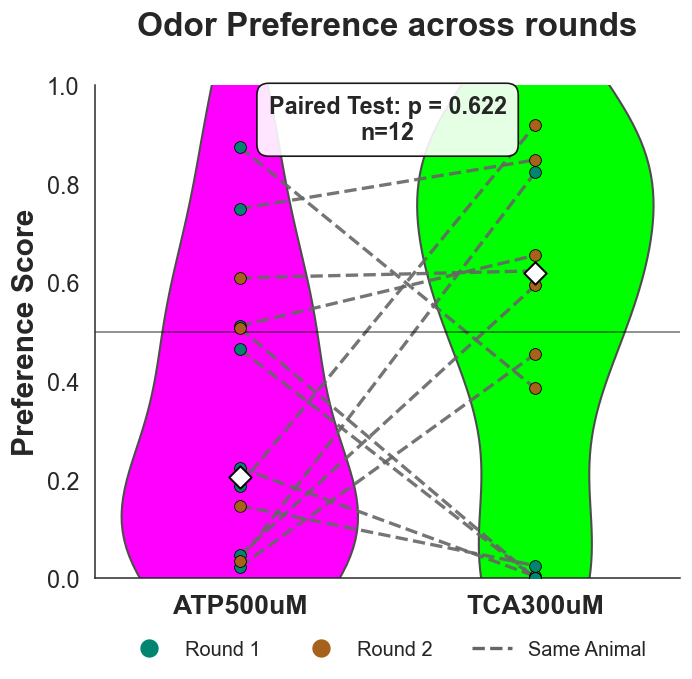

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import wilcoxon

def plot_linked_odor_comparison_final(trial_stats, save_dir):
    # 1. Prepare Data
    df = trial_stats[trial_stats["Session_Order"].isin([1, 2])].copy()
    
    # Pivot to get one row per animal with both odor scores
    wide = df.pivot(index="Animal_ID", columns="Odor", values="Avg_Preference").dropna()
    
    # Map for spot coloring (Round 1 vs Round 2)
    round_map = df.set_index(["Animal_ID", "Odor"])["Session_Order"].to_dict()
    
    # 2. Setup Plot Aesthetics
    sns.set_style("white")
    fig, ax = plt.subplots(figsize=(6, 6))
    
    odors = ["ATP500uM", "TCA300uM"] 
    # ATP (Magenta), TCA (Lime Green #00FF00) - No Opacity
    violin_palette = {"ATP500uM": "magenta", "TCA300uM": "#00FF00"}
    # Round Colors
    round_palette = {1: "#018571", 2: "#a6611a"}

    # 3. Plot Violins (Full Opacity)
    sns.violinplot(
        data=df, x="Odor", y="Avg_Preference", order=odors,
        palette=violin_palette, inner=None, ax=ax, saturation=1
    )
    # Explicitly set alpha to 1 for all violin patches
    for patch in ax.collections:
        patch.set_alpha(1.0)
        # --- MEDIAN DIAMONDS (surgical add; one per odor) ---
    MEDIAN_SIZE = 90       # tweak
    MEDIAN_EDGE_LW = 1.2   # tweak
    for i, odor in enumerate(odors):
        v = pd.to_numeric(df.loc[df["Odor"] == odor, "Avg_Preference"], errors="coerce").astype(float).values
        v = v[np.isfinite(v)]
        if v.size == 0:
            continue
        med = float(np.median(v))
        ax.scatter(
            i, med,
            marker="D",
            s=MEDIAN_SIZE,
            facecolor="white",
            edgecolor="black",
            linewidth=MEDIAN_EDGE_LW,
            zorder=4,
            clip_on=False,
        )

    # 4. Draw Linked Lines (Increased Visibility) and Spots
    for anim_id, row in wide.iterrows():
        y_values = [row[odors[0]], row[odors[1]]]
        x_values = [0, 1]
        
        # Linking lines: Darker gray and thicker
        ax.plot(x_values, y_values, color="#666666", linestyle="--", 
                alpha=0.9, linewidth=2.0, zorder=2)
        
        # Scatter spots: Colored by Round
        for i, odor in enumerate(odors):
            rnd = round_map.get((anim_id, odor))
            ax.scatter(i, row[odor], color=round_palette[rnd], 
                       s=50, edgecolors="black", linewidth=0.5, alpha=1.0, zorder=3)

    # 5. Statistics (Paired: ATP vs TCA)
    stat, p_val = wilcoxon(wide[odors[0]], wide[odors[1]])
    p_text = f"p = {p_val:.3f}" if p_val >= 0.001 else "p < 0.001"
    
    ax.text(0.5, 0.98, f"Paired Test: {p_text}\nn={len(wide)}", 
            ha='center', va='top', fontweight='bold', fontsize=14,
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))

    # 6. Final Aesthetic Revisions (Enlarged Text)
    ax.axhline(0.5, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    # Axis Limits and Ticks
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    
    # Scaling up all text
    ax.set_xticklabels(odors, fontweight='bold', fontsize=16)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlabel("") 
    ax.set_ylabel("Preference Score", fontweight='bold', fontsize=18)
    ax.set_title("Odor Preference across rounds", pad=30, fontsize=20, fontweight='bold')
    
    # Legend - Enlarged
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Round 1',
               markerfacecolor=round_palette[1], markersize=12),
        Line2D([0], [0], marker='o', color='w', label='Round 2',
               markerfacecolor=round_palette[2], markersize=12),
        Line2D([0], [0], color='#666666', linestyle='--', label='Same Animal', lw=2)
    ]
    ax.legend(handles=legend_elements, loc='lower center', 
              bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=12)

    sns.despine()
    plt.tight_layout()
    
    # 7. Save
    if not os.path.exists(save_dir): 
        os.makedirs(save_dir)
    save_path = os.path.join(save_dir, "high_visibility_odor_plot.svg")
    plt.savefig(save_path, format='svg', bbox_inches='tight', transparent=True)
    save_path_pdf = os.path.join(save_dir, "high_visibility_odor_plot.pdf")    
    plt.savefig(save_path_pdf, format="pdf", bbox_inches="tight", transparent=True)

    
    print(f"High-visibility plot saved to: {save_path}")
    plt.show()

# Execution
save_path = r"U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\2pAblation_plots\202601_plots"
plot_linked_odor_comparison_final(trial_stats, save_path)

File successfully saved to: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\2pAblation_plots\202601_plots\odor_preference_round_comparison_spots.svg


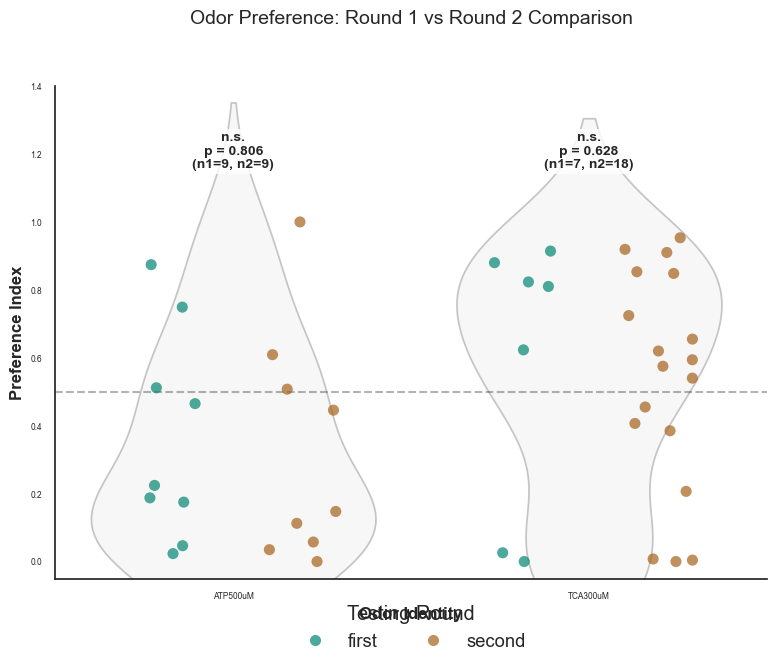

In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import mannwhitneyu, ttest_ind, shapiro

def plot_odor_pref_by_round_spots(trial_stats, save_dir):
    # 1. Prepare Data
    # Keep only Round 1 and Round 2
    df = trial_stats[trial_stats["Session_Order"].isin([1, 2])].copy()
    df["Round"] = df["Session_Order"].map({1: "first", 2: "second"})
    df["Round"] = pd.Categorical(df["Round"], categories=["first", "second"], ordered=True)
    
    # Define Palette (Teal for first round, Orange for second round)
    round_palette = {"first": "#018571", "second": "#a6611a"}
    
    # 2. Setup Figure
    sns.set_style("white")
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Sort odors to ensure consistent ATP / TCA placement
    odors = sorted(df["Odor"].unique()) 

    # 3. Plot Violins (1 per odor)
    # Using a neutral light gray for the violin to highlight the colored spots
    sns.violinplot(
        data=df, x="Odor", y="Avg_Preference", order=odors,
        color="#f0f0f0", inner=None, ax=ax, alpha=0.5
    )
    
    # 4. Overlay Spots (Colored by Round)
    # dodge=True separates the Round 1 and Round 2 spots slightly for clarity
    sns.stripplot(
        data=df, x="Odor", y="Avg_Preference", order=odors,
        hue="Round", palette=round_palette, 
        dodge=True, size=8, alpha=0.7, jitter=0.2, ax=ax
    )

    # 5. Statistics & Annotations
    # Compare Round 1 vs Round 2 for each odor independently
    for i, odor in enumerate(odors):
        odor_df = df[df["Odor"] == odor]
        r1 = odor_df[odor_df["Round"] == "first"]["Avg_Preference"].dropna()
        r2 = odor_df[odor_df["Round"] == "second"]["Avg_Preference"].dropna()
        
        n1, n2 = len(r1), len(r2)
        
        if n1 > 1 and n2 > 1:
            # Normality check to select between t-test and Mann-Whitney
            try:
                norm_p = min(shapiro(r1)[1], shapiro(r2)[1])
                if norm_p < 0.05:
                    stat, p_val = mannwhitneyu(r1, r2)
                    method = "MWU"
                else:
                    stat, p_val = ttest_ind(r1, r2)
                    method = "t-test"
            except:
                stat, p_val = mannwhitneyu(r1, r2)
                method = "MWU"
                
            # Formatting p-value and stars
            p_text = f"p = {p_val:.3f}" if p_val >= 0.001 else "p < 0.001"
            stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
            
            # Position annotation box above the violin
            ax.text(i, 1.15, f"{stars}\n{p_text}\n(n1={n1}, n2={n2})", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

    # 6. Aesthetics
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.3) # Chance level
    ax.set_ylim(-0.05, 1.4)
    ax.set_xlabel("Odor Identity", fontweight='bold', fontsize=12)
    ax.set_ylabel("Preference Index", fontweight='bold', fontsize=12)
    ax.set_title("Odor Preference: Round 1 vs Round 2 Comparison", pad=45, fontsize=14)
    
    # Legend: Cleanup to only show Round colors
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title="Testing Round", loc='lower center', 
               bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
    
    sns.despine()
    plt.tight_layout()
    
    # 7. Save as SVG for Illustrator
    if not os.path.exists(save_dir): 
        os.makedirs(save_dir)
    save_path = os.path.join(save_dir, "odor_preference_round_comparison_spots.svg")
    plt.savefig(save_path, format='svg', bbox_inches='tight', transparent=True)
    
    print(f"File successfully saved to: {save_path}")
    plt.show()

# Execution
save_path = r"U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\behavioral data\2pAblation_plots\202601_plots"
plot_odor_pref_by_round_spots(trial_stats, save_path)